# INTRODUCTION

This dataset contains comprehensive information on 2,392 high school students, detailing their demographics, study habits, parental involvement, extracurricular activities, and academic performance. The target variable, GradeClass, classifies students' grades into distinct categories, providing a robust dataset for educational research, predictive modeling, and statistical analysis.

  # Data Source and Description



  ## Dataset Usage and Attribution Notice
This datase is owned byy Rabie El Kharoue. It is made available under the CC BY 4.0 license, allowing anyone to use the dataset in any form as long as proper citation is given to the author. A DOI is provided for proper referencing

  ## About this file


Student Information
Student ID
StudentID: A unique identifier assigned to each student (1001 to 3392).
Demographic Details
Age: The age of the students ranges from 15 to 18 years.
Gender: Gender of the students, where 0 represents Male and 1 represents Female.
Ethnicity: The ethnicity of the students, coded as follows:
0: Caucasian
1: African American
2: Asian
3: Other
ParentalEducation: The education level of the parents, coded as follows:
0: None
1: High School
2: Some College
3: Bachelor's
4: Higher
Study Habits
StudyTimeWeekly: Weekly study time in hours, ranging from 0 to 20.
Absences: Number of absences during the school year, ranging from 0 to 30.
Tutoring: Tutoring status, where 0 indicates No and 1 indicates Yes.
Parental Involvement
ParentalSupport: The level of parental support, coded as follows:
0: None
1: Low
2: Moderate
3: High
4: Very High
Extracurricular Activities
Extracurricular: Participation in extracurricular activities, where 0 indicates No and 1 indicates Yes.
Sports: Participation in sports, where 0 indicates No and 1 indicates Yes.
Music: Participation in music activities, where 0 indicates No and 1 indicates Yes.
Volunteering: Participation in volunteering, where 0 indicates No and 1 indicates Yes.
Academic Performance
GPA: Grade Point Average on a scale from 2.0 to 4.0, influenced by study habits, parental involvement, and extracurricular activities.
Target Variable: Grade Class
GradeClass: Classification of students' grades based on GPA:
0: 'A' (GPA >= 3.5)
1: 'B' (3.0 <= GPA < 3.5)
2: 'C' (2.5 <= GPA < 3.0)
3: 'D' (2.0 <= GPA < 2.5)
4: 'F' (GPA < 2.0)

## Problem Statement

You are tasked with investigating the relationship between various socioeconomic factors and student academic performance in public schools. The goal is to identify key factors that significantly influence performance and quantify their impact.

## Skills and Concepts Demonstrated

-Understanding the Dataset
-Load the Dataset
-Data Cleaning and Preprocessing
-Exploratory Data Analysis (EDA)
-Visualization
-Machine Learning
-Derive Insights
    

## PROJECT STRATEGY

Jupyter Notebook was used to carry out my analysis throughout this project. After downloading the dataset from (https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset?resource=download), I studied the dataset to know the necessary Python libraries and machine learning models I’ll be making use of. Then, I imported  all the necessary libraries required.

**Import Python Libraries**

In [12]:
import pandas as pd  
import numpy as np  
import seaborn as sns  
import matplotlib.pyplot as plt  
import plotly.express as px  
from scipy.stats import chi2_contingency, f_oneway, pearsonr  
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler, LabelEncoder  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score  


**Load Student Performance Data**

In [118]:
# Loading the dataset
data = pd.read_excel("Student_performance_data.xlsx", sheet_name="Student_performance_data _")

In [21]:
data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


In [120]:
# Inspecting the dataset
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [29]:
data.nunique()

StudentID            2392
Age                     4
Gender                  2
Ethnicity               4
ParentalEducation       5
StudyTimeWeekly      2392
Absences               30
Tutoring                2
ParentalSupport         5
Extracurricular         2
Sports                  2
Music                   2
Volunteering            2
GPA                  2371
GradeClass              5
dtype: int64

**Exploratory Data Analysis (EDA)**

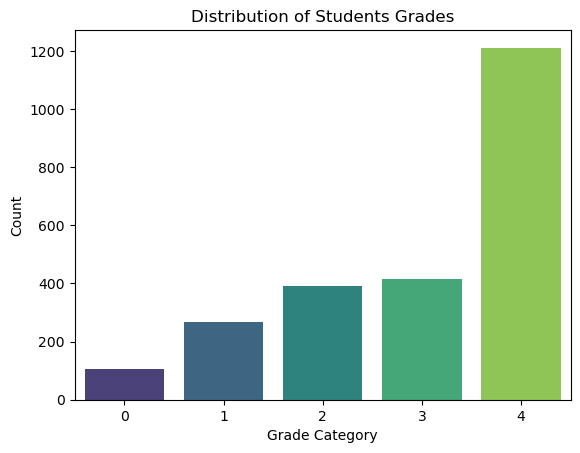

In [123]:
# Grades Distribution
sns.countplot(x='GradeClass', data=data, palette='viridis')
plt.title("Distribution of Students Grades")
plt.xlabel("Grade Category")
plt.ylabel("Count")
plt.show()

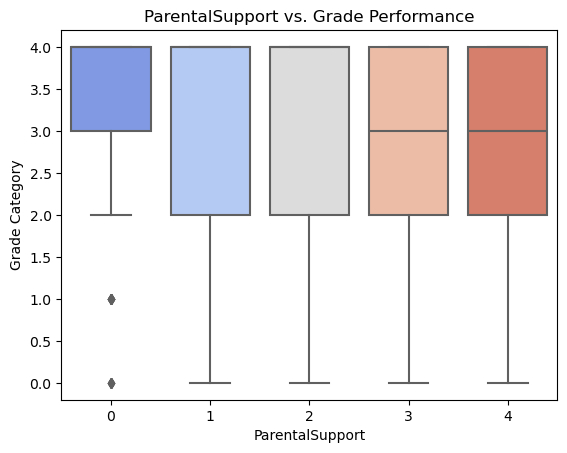

In [44]:
# ParentalSupport vs. Grade Performanc
sns.boxplot(x='ParentalSupport', y='GradeClass', data=data, palette='coolwarm')
plt.title("ParentalSupport vs. Grade Performance")
plt.xlabel("ParentalSupport")
plt.ylabel("Grade Category")
plt.show()

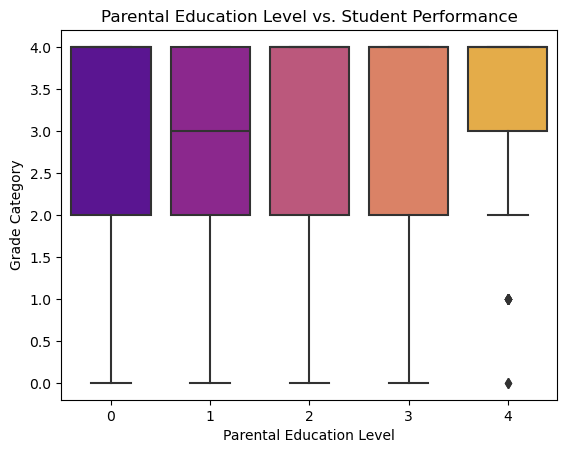

In [125]:
# Parental Education Level vs. Student Performance
sns.boxplot(x='ParentalEducation', y='GradeClass', data=data, palette='plasma')
plt.title("Parental Education Level vs. Student Performance")
plt.xlabel("Parental Education Level")
plt.ylabel("Grade Category")
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


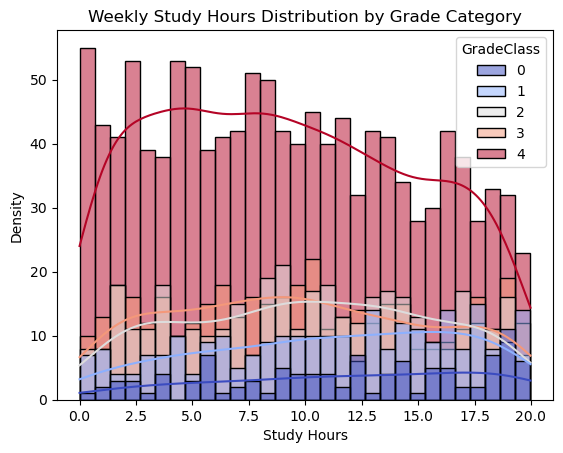

In [50]:
# Weekly Study Hours Distribution by Grade Category
sns.histplot(data, x='StudyTimeWeekly', hue='GradeClass', kde=True, bins=30, palette="coolwarm")  
plt.title("Weekly Study Hours Distribution by Grade Category")  
plt.xlabel("Study Hours")  
plt.ylabel("Density")  
plt.show()  


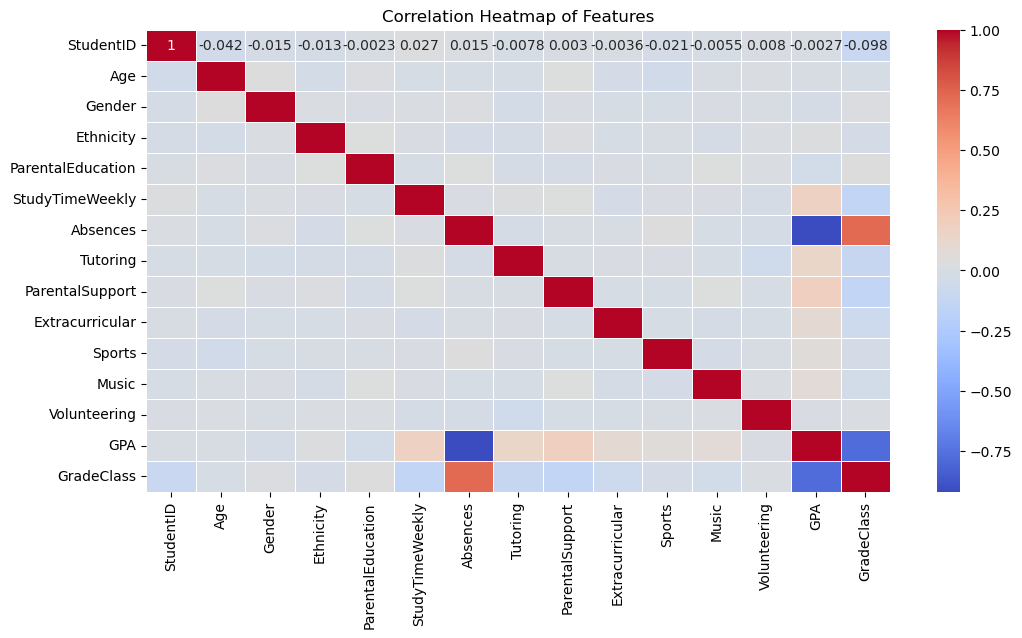

In [62]:
# Relationships Between Factors
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)  
plt.title("Correlation Heatmap of Features")  
plt.show()  


**Statistical Testing**

In [64]:
# Perform Chi-Square Test
contingency_table = pd.crosstab(data['ParentalEducation'], data['GradeClass'])  
chi2, p, dof, expected = chi2_contingency(contingency_table)  
print(f"Chi-Square Test: {chi2:.2f}, p-value: {p:.5f}")  


Chi-Square Test: 14.88, p-value: 0.53330


In [76]:
# Perform ANOVA Test
f_stat, p_val = f_oneway(
    data[data['GradeClass'] == 0]['StudyTimeWeekly'],  
    data[data['GradeClass'] == 1]['StudyTimeWeekly'],  
    data[data['GradeClass'] == 2]['StudyTimeWeekly']  
)  
print(f"ANOVA Test: F-statistic = {f_stat:.2f}, p-value = {p_val:.5f}")  


ANOVA Test: F-statistic = 5.31, p-value = 0.00515


In [130]:
# Prepare Data for Prediction
data = pd.get_dummies(data, drop_first=True)  
X = data.drop(columns=["GradeClass"])  
y = data["GradeClass"]  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
scaler = StandardScaler()  
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)  


In [82]:
# Predicting Student Grades (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)  
clf.fit(X_train, y_train)  
y_pred = clf.predict(X_test)  
print("Accuracy:", accuracy_score(y_test, y_pred))  
print(classification_report(y_test, y_pred))  


Accuracy: 0.9123173277661796
              precision    recall  f1-score   support

           0       0.91      0.45      0.61        22
           1       0.77      0.88      0.82        49
           2       0.89      0.87      0.88        85
           3       0.90      0.90      0.90        86
           4       0.96      0.98      0.97       237

    accuracy                           0.91       479
   macro avg       0.88      0.82      0.83       479
weighted avg       0.91      0.91      0.91       479



In [84]:
# Predicting Final Score (Linear Regression)
regressor = LinearRegression()  
regressor.fit(X_train, y_train)  
y_pred_reg = regressor.predict(X_test)  
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_reg):.2f}")  
print(f"R-squared Score: {r2_score(y_test, y_pred_reg):.2f}")  


Mean Absolute Error: 0.54
R-squared Score: 0.64


## INSIGHTS GAINED THROUGH ANALYSIS



**Key Factors and Their Relationships with Student Performance**

Parental Education and Support: Higher levels of parental education and support are strongly associated with better student GPA. This suggests a supportive home environment and access to resources contribute to academic succes.
Study Time: Increased study time is positively linked to higher GPA, indicating the importance of dedicated effort in achieving academic greatness. 
Absences: Higher absenteeism negatively correlates with GPA, highlighting the detrimental effect of missing classes on student performance. Socioeconomic Status (SES): The engineered SES index, incorporating parental education, support, and study time, shows a positive correlation with GPA, suggesting students from higher SES backgrounds tend to perform better academically. 

Interaction Effects:
Study Time and Parental Education: The positive effect of study time on GPA is amplified for students with higher parental education levels. This suggests that students with more educated parents may be better equipped to utilize study time effectively or have access to resources that enhance learning. Absences and Parental Support: The negative impact of absences on GPA is mitigated for students with strong parental support. This indicates that parental support can help students overcome challenges posed by missed classes, possibly through emotional support or assistance in catching up on missed work. Model Performance and Feature Importance: Random Forest and Linear Regression performed well in predicting grades. This indicates these models effectively captured the relationships between features and target variable. Feature importance analysis revealed the most influential factors in predicting GPA, with parental education, support, study time, and absences being among the top contributors. 

Overall Insights ad Implications:
Socioeconomic factors play a crucial role in student academic performance. Parental education, support, study time, and absences are significant predictors of GPA. Interaction effects highlight the complex interplay between these factors. The impact of one factor on GPA can depend on the levels of other factors, emphasizing the need for a holistic understanding of student needs. Targeted interventions and support systems should consider these interaction effects. For instance, programs aimed at improving study habits might be more effective when tailored to different parental education levels. Similarly, support for students with high absenteeism could be enhanced individual circumstances.

## Summary of Key Recommendations for Stakeholders:

For Educators:

Targeted Interventions: Design and implement interventions tailored to specific student needs, considering socioeconomic factors and interaction effects. For example:
Offer study skills workshops specifically for students with lower parental education levels to enhance their ability to utilize study time effectively.
Provide individualized support for students with high absenteeism, involving parents to create a collaborative approach to address the underlying causes.
Promote Parental Involvement: Encourage active parental engagement in students' education through workshops, communication channels, and resources to foster a supportive home environment.
Address Absenteeism: Develop strategies to minimize absenteeism by addressing underlying causes, providing academic support for missed work, and promoting a positive school climate.
Data-Driven Decision Making: Utilize data analysis to identify at-risk students, monitor progress, and evaluate the effectiveness of interventions to continuously improve student support strategies.
    
For School Administrators:

Resource Allocation: Allocate resources strategically to address the specific needs of students from different socioeconomic backgrounds, ensuring equitable access to learning opportunities.
Professional Development: Provide professional development for teachers and staff on the impact of socioeconomic factors on student performance and effective strategies for supporting diverse learners.
Community Partnerships: Collaborate with community organizations to provide additional resources and support services for students and families, addressing needs beyond the classroom.
Data-Informed Policies: Develop school policies and practices that are informed by data analysis, promoting equity and inclusivity in education.

For Policymakers:

Early Childhood Education: Invest in high-quality early childhood education programs to address disparities in academic preparedness and provide a strong foundation for future learning.
Family Support Programs: Implement family support programs that provide resources and guidance to parents, empowering them to actively participate in their children's education.
Social Welfare Policies: Address socioeconomic inequalities through social welfare policies that provide access to basic needs, such as food, housing, and healthcare, creating a more stable environment for students and families.
Evidence-Based Practices: Promote the use of evidence-based practices in education, ensuring that interventions and policies are grounded in research and data-driven insights.
                                                                                                                                                                    
For Parents:

Active Involvement: Engage actively in your child's education by communicating with teachers, supporting their learning at home, and creating a positive learning environment.
Advocate for Resources: Advocate for school resources and policies that support the needs of all students, ensuring equitable access to quality education.
Community Engagement: Connect with community organizations and support programs that offer additional resources and guidance for families.
Open Communication: Maintain open communication with your child about their academic progress, challenges, and aspirations, providing ongoing support and encouragement.